# 01 – Regime-Conditioned Alpha Setup


V1 tested whether a simple Bayesian fair value model could detect exploitable mispricing in Polymarket prediction markets.

The result was negative: Bayesian mispricing alone did not produce robust trading alpha.

V2 shifted the focus from alpha generation to market efficiency.

The key finding was that prediction markets are not homogeneous. Instead, they appear to organize into two information-processing regimes:

1. **Information Processing Markets**
2. **Anchored / Noisy Markets**

These regimes showed dramatically different forecast accuracy.

V3 starts from that discovery.

The central question is no longer: Are prediction markets efficient?

but rather: Can information-processing regimes help isolate where tradable alpha may exist?

---

## Research Question

Does Bayesian mispricing become more useful when conditioned on market regime?

---

## Core Hypothesis

A global Bayesian mispricing signal may fail because it treats all markets as identical.

However, mispricing may behave differently across information regimes.

In particular:

* Information Processing Markets may quickly eliminate mispricing.
* Anchored / Noisy Markets may update slowly and preserve exploitable inefficiencies.

Therefore, alpha may not exist globally, but may exist conditionally.

---

## Notebook Objective

This notebook prepares the V3 modeling dataset by merging:

1. Bayesian fair value outputs from V1
2. Information-dynamics features from V2
3. Market-state cluster labels from V2
4. Final outcomes and market probabilities

The resulting dataset will allow us to test whether mispricing performance differs across market regimes.

---


## Regime Definitions

### Information Processing Markets

Markets characterized by:

* High Drawdown
* High Reversals
* High Probability Range
* Low Entropy

These markets tend to incorporate information efficiently and converge toward accurate forecasts.

---

### Regime 1  Anchored / Noisy Markets

Markets characterized by:

* Low Drawdown
* Low Reversals
* Low Probability Range
* High Entropy

These markets tend to update slowly, remain noisy, and exhibit larger forecast errors.

---

## Main Test Prepared by This Notebook

The final dataset will support the following analysis:

```text
Bayesian Mispricing
        ↓
Condition on Market Regime
        ↓
Signal Quality by Regime
```

The next notebooks will evaluate whether BUY/SELL signals perform better inside specific market regimes.

---


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

fair_value = pd.read_csv("../data/processed/market_dataset_with_fair_value.csv")
df_model_v2 = pd.read_csv("../data/processed/df_model_v2.csv")

fair_cols = [
    "market_id",
    "question",
    "outcome",
    "final_probability",
    "bayesian_fair_probability",
    "mispricing"
]

features = [
    "realized_volatility",
    "probability_range",
    "trend",
    "max_drawdown",
    "reversals",
    "shannon_entropy",
    "skewness",
    "kurtosis",
    "autocorrelation"
]


fair_value_base = fair_value[fair_cols].copy()
info_base = df_model_v2[["market_id", "abs_surprise"] + features].copy()
regime_alpha = fair_value_base.merge(info_base,on="market_id", how="left")

In [2]:
regime_alpha.shape

(43, 16)

In [3]:
regime_alpha.isna().sum().sort_values(ascending=False)

shannon_entropy              4
autocorrelation              4
market_id                    0
question                     0
bayesian_fair_probability    0
mispricing                   0
outcome                      0
final_probability            0
realized_volatility          0
abs_surprise                 0
probability_range            0
trend                        0
reversals                    0
max_drawdown                 0
skewness                     0
kurtosis                     0
dtype: int64

In [4]:
X = regime_alpha[features]
preprocess = Pipeline([("imputer", SimpleImputer(strategy="median")),("scaler", StandardScaler())])
X_scaled = preprocess.fit_transform(X)

In [5]:
kmeans = KMeans(n_clusters=2,random_state=42,n_init=20)
regime_alpha["cluster"] = kmeans.fit_predict(X_scaled)

In [6]:
cluster_summary = regime_alpha.groupby("cluster")[["max_drawdown", "reversals", "probability_range", "shannon_entropy", "abs_surprise"]
].mean()
cluster_summary

,max_drawdown,reversals,probability_range,shannon_entropy,abs_surprise
cluster,,,,,
0,0.870148,702.843750,0.617969,0.181319,0.040422
1,0.447587,96.727273,0.218455,0.568352,0.340091


In [7]:
regime_map = {0: "Information Processing",
              1: "Anchored / Noisy"}

regime_alpha["market_regime"] = regime_alpha["cluster"].map(regime_map)

In [8]:
regime_alpha["abs_mispricing"] = regime_alpha["mispricing"].abs()
regime_alpha[[ "market_id",
              "question",
              "mispricing",
              "abs_mispricing",
              "abs_surprise"]].head()

,market_id,question,mispricing,abs_mispricing,abs_surprise
0,248594,Will Hunter Biden be federally indicted by May...,0.018462,0.018462,0.020
1,249778,MLB: Cincinnati Reds vs. Pittsburgh Pirates 20...,0.050000,0.050000,0.450
2,250474,Did US GDP grow 2.5% or more in Q1 2023?,-0.026667,0.026667,0.360
3,251025,Will Ron DeSantis file to run for president by...,-0.095000,0.095000,0.005
4,251027,USD/TRY (Turkish Lira) above 19.75 on May 22?,-0.158333,0.158333,0.175


In [9]:
regime_alpha.to_csv("../data/processed/regime_alpha_dataset.csv",index=False)

# Is Bayesian mispricing different by regime?

In [10]:
regime_alpha.groupby("market_regime")["abs_mispricing"].agg(["count", "mean", "median", "std", "min", "max"])

,count,mean,median,std,min,max
market_regime,,,,,,
Anchored / Noisy,11,0.075224,0.045000,0.074876,0.021538,0.265
Information Processing,32,0.056990,0.037962,0.047882,0.011538,0.265


In [11]:
regime_alpha.groupby("market_regime")["mispricing"].agg(["count", "mean", "median", "std", "min", "max"])

,count,mean,median,std,min,max
market_regime,,,,,,
Anchored / Noisy,11,0.011308,0.028462,0.108121,-0.158333,0.265
Information Processing,32,-0.000973,0.030962,0.075129,-0.108333,0.265


In [12]:
regime_alpha["signal"] = np.where(regime_alpha["mispricing"] > 0, "BUY", "SELL")

regime_alpha.groupby(["market_regime", "signal"])["outcome"].agg(["count", "mean"]) 

count      mean
market_regime          signal                 
Anchored / Noisy       BUY         6  0.500000
                       SELL        5  0.200000
Information Processing BUY        20  0.000000
                       SELL       12  0.833333

 # Does the sign of mispricing contain predictive information?

In [13]:
# Normal directional signal
regime_alpha["pred_normal"] = np.where(regime_alpha["mispricing"] > 0, 1, 0)
# Inverted directional signal
regime_alpha["pred_inverted"] = np.where(regime_alpha["mispricing"] > 0, 0, 1)
regime_alpha["correct_normal"] = (regime_alpha["pred_normal"] == regime_alpha["outcome"])
regime_alpha["correct_inverted"] = (regime_alpha["pred_inverted"] == regime_alpha["outcome"])

accuracy_by_regime = regime_alpha.groupby("market_regime")[["correct_normal", "correct_inverted"]].mean()
accuracy_by_regime


,correct_normal,correct_inverted
market_regime,,
Anchored / Noisy,0.636364,0.363636
Information Processing,0.062500,0.937500


In [14]:
thresholds = [0.00, 0.025, 0.05, 0.10, 0.15, 0.20]

results = []

for t in thresholds:
    temp = regime_alpha[regime_alpha["abs_mispricing"] >= t].copy()
    
    for regime in temp["market_regime"].unique():
        subset = temp[temp["market_regime"] == regime]
        
        if len(subset) == 0:
            continue
        
        normal_acc = (subset["pred_normal"] == subset["outcome"]).mean()
        inverted_acc = (subset["pred_inverted"] == subset["outcome"]).mean()
        
        results.append({
            "threshold": t,
            "market_regime": regime,
            "trades": len(subset),
            "normal_accuracy": normal_acc,
            "inverted_accuracy": inverted_acc
        })

threshold_results = pd.DataFrame(results)
threshold_results

,threshold,market_regime,trades,normal_accuracy,inverted_accuracy
0,0.000,Information Processing,32,0.062500,0.937500
1,0.000,Anchored / Noisy,11,0.636364,0.363636
2,0.025,Anchored / Noisy,10,0.600000,0.400000
3,0.025,Information Processing,28,0.035714,0.964286
4,0.050,Information Processing,11,0.000000,1.000000
5,0.050,Anchored / Noisy,4,0.500000,0.500000
6,0.100,Anchored / Noisy,2,0.500000,0.500000
7,0.100,Information Processing,2,0.000000,1.000000
8,0.150,Anchored / Noisy,2,0.500000,0.500000
9,0.150,Information Processing,1,0.000000,1.000000


In [15]:
threshold_results.sort_values(
    ["market_regime", "threshold"]
)

,threshold,market_regime,trades,normal_accuracy,inverted_accuracy
1,0.000,Anchored / Noisy,11,0.636364,0.363636
2,0.025,Anchored / Noisy,10,0.600000,0.400000
5,0.050,Anchored / Noisy,4,0.500000,0.500000
6,0.100,Anchored / Noisy,2,0.500000,0.500000
8,0.150,Anchored / Noisy,2,0.500000,0.500000
10,0.200,Anchored / Noisy,1,1.000000,0.000000
0,0.000,Information Processing,32,0.062500,0.937500
3,0.025,Information Processing,28,0.035714,0.964286
4,0.050,Information Processing,11,0.000000,1.000000
7,0.100,Information Processing,2,0.000000,1.000000


In [16]:
# Regimen Confusion Matrix 
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


subset = regime_alpha[regime_alpha["market_regime"] == "Information Processing"]

cm = confusion_matrix(subset["outcome"],subset["pred_inverted"])
cm

array([[20,  2],
       [ 0, 10]])

In [17]:

print(classification_report(subset["outcome"],subset["pred_inverted"]))

              precision    recall  f1-score   support

           0       1.00      0.91      0.95        22
           1       0.83      1.00      0.91        10

    accuracy                           0.94        32
   macro avg       0.92      0.95      0.93        32
weighted avg       0.95      0.94      0.94        32



Preliminary Finding

In Information Processing markets, Bayesian mispricing exhibits a strongly contrarian relationship with realized outcomes.

In [18]:
regime_alpha.groupby("market_regime").apply(lambda x: x["mispricing"].corr(x["outcome"] - x["final_probability"]))

market_regime
Anchored / Noisy          0.554222
Information Processing   -0.455096
dtype: float64

<Axes: xlabel='mispricing', ylabel='outcome_final_error'>

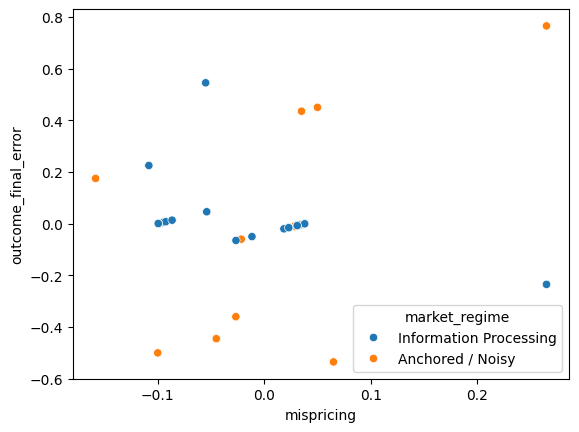

In [19]:
regime_alpha["outcome_final_error"] = (regime_alpha["outcome"]- regime_alpha["final_probability"])
sns.scatterplot(data=regime_alpha,x="mispricing",y="outcome_final_error",hue="market_regime")

Bayesian mispricing does not exhibit a universal relationship with future outcomes. Instead, its predictive direction reverses across information-processing regimes. In Anchored/Noisy markets, Bayesian signals align with future errors, while in Information Processing markets the signal becomes strongly contrarian.

In [20]:
from scipy.stats import bootstrap
#Bootstrap Correlation CI

import numpy as np

def bootstrap_corr(x, y, n_boot=10000):
    corrs = []
    n = len(x)
    for _ in range(n_boot):
        idx = np.random.choice(np.arange(n),size=n,replace=True)

        corr = np.corrcoef(x.iloc[idx],y.iloc[idx])[0, 1]
        corrs.append(corr)

    return np.percentile(corrs, [2.5, 97.5]), corrs


anchored = regime_alpha[regime_alpha["market_regime"] == "Anchored / Noisy"]
future_error = (anchored["outcome"]- anchored["final_probability"])
ci_anchored, corrs_anchored = bootstrap_corr(anchored["mispricing"],future_error)
print(ci_anchored)

[-0.29484165  0.92352433]


In [21]:
info = regime_alpha[regime_alpha["market_regime"] == "Information Processing"]

future_error = (info["outcome"]- info["final_probability"])

ci_info, corrs_info = bootstrap_corr(info["mispricing"],future_error)

print(ci_info)

[-0.82132871 -0.16430241]


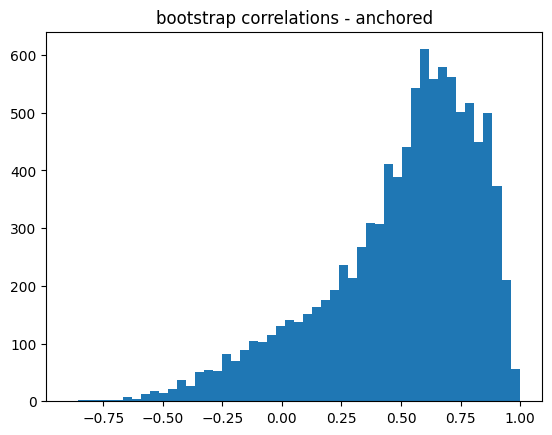

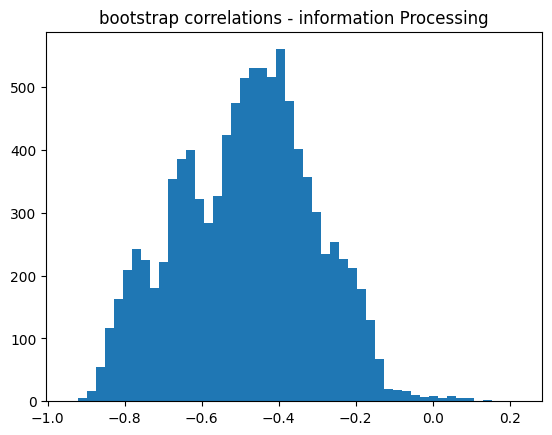

In [22]:

plt.hist(corrs_anchored, bins=50)
plt.title("bootstrap correlations - anchored")
plt.show()

plt.hist(corrs_info, bins=50)
plt.title("bootstrap correlations - information Processing")
plt.show()

# Does the regime add information?

In [24]:
import statsmodels.formula.api as smf

reg_df = regime_alpha.copy()
reg_df["future_error"] = (reg_df["outcome"]- reg_df["final_probability"])
reg_df["regime_binary"] = np.where(reg_df["market_regime"] == "Information Processing",1,0)

model = smf.ols(
    """
    future_error
    ~ mispricing
    + regime_binary
    + mispricing:regime_binary
    """,data=reg_df).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           future_error   R-squared:                       0.290
Model:                            OLS   Adj. R-squared:                  0.236
Method:                 Least Squares   F-statistic:                     5.319
Date:                Wed, 03 Jun 2026   Prob (F-statistic):            0.00360
Time:                        14:33:27   Log-Likelihood:                 9.4478
No. Observations:                  43   AIC:                            -10.90
Df Residuals:                      39   BIC:                            -3.851
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

Regime-Dependent Mispricing Effect

A linear interaction model revealed a statistically significant regime-dependent effect of Bayesian mispricing on future forecast errors.

The interaction coefficient was:

$ β=−2.914  $

with

$ p=0.001 $

indicating that the predictive direction of Bayesian mispricing reverses across market regimes.

In Anchored/Noisy markets, positive mispricing is associated with positive future errors, whereas in Information Processing markets the relationship becomes negative.

These findings suggest that Bayesian fair-value signals are not universally exploitable and must be interpreted conditional on the market's information-processing regime.

# Conclusions

1. Bayesian mispricing does not behave uniformly across prediction markets.

2. Information-processing regimes reverse the predictive direction of Bayesian signals.

3. The interaction between market regime and mispricing is statistically significant (p=0.001).

4. Any alpha extraction strategy must therefore be conditioned on regime identification.